# Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("data/googleplaystore.csv")

# Preview Dataset
display(df.head())

# Dataset Size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Rows: 10841
Columns: 13


# Dataset Overview

In [2]:
# Column Names
print(df.columns.tolist())

# Dataset Information
df.info()

# Statistical Summary
display(df.describe())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


# Data Cleaning

In [4]:
# Missing Values
display(df.isnull().sum())

# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()

print("Dataset Shape After Cleaning:", df.shape)

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate Rows: 483
Dataset Shape After Cleaning: (10358, 13)


# Data Cleaning & Feature Preparation

In [6]:
# Remove rows with missing ratings
df = df.dropna(subset=["Rating"])

# Clean Installs column
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Clean Price column
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Check cleaned data
display(df[["Rating", "Installs", "Price"]].head())

,Rating,Installs,Price
0,4.1,10000.0,0.0
1,3.9,500000.0,0.0
2,4.7,5000000.0,0.0
3,4.5,50000000.0,0.0
4,4.3,100000.0,0.0


# App Ratings Analysis

count    8893.000000
mean        4.189542
std         0.545452
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

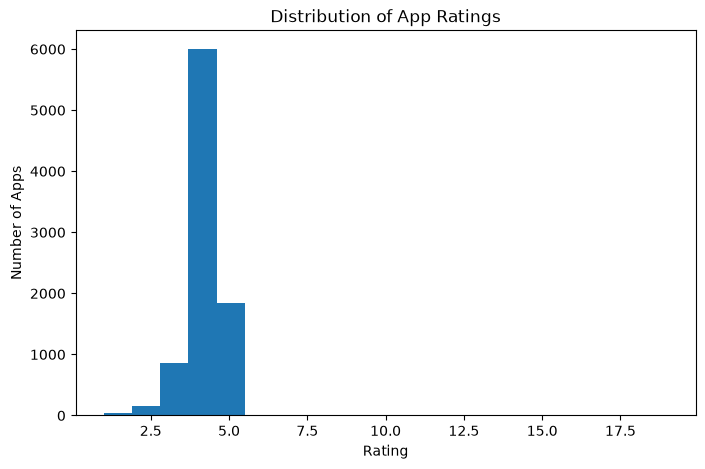

In [12]:
# Rating Statistics
display(df["Rating"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=20)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

# Category Analysis

Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64

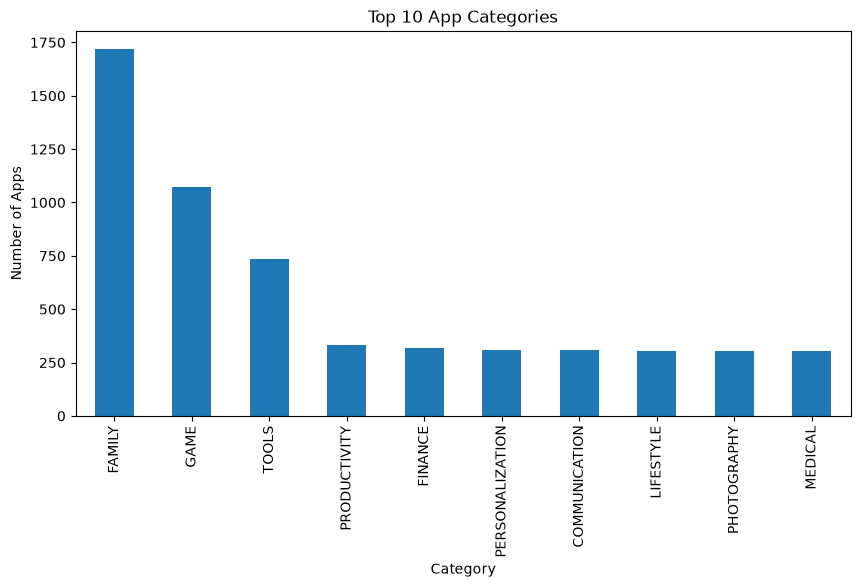

In [13]:
# Top Categories
category_counts = df["Category"].value_counts().head(10)

display(category_counts)

plt.figure(figsize=(10,5))

category_counts.plot(kind="bar")

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.show()

# Installs Analysis

count    8.892000e+03
mean     1.648965e+07
std      8.637600e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

,App,Installs
152,Google Play Books,1.000000e+09
335,Messenger – Text and Video Chat for Free,1.000000e+09
336,WhatsApp Messenger,1.000000e+09
338,Google Chrome: Fast & Secure,1.000000e+09
340,Gmail,1.000000e+09
341,Hangouts,1.000000e+09
382,Messenger – Text and Video Chat for Free,1.000000e+09
386,Hangouts,1.000000e+09
391,Skype - free IM & video calls,1.000000e+09
411,Google Chrome: Fast & Secure,1.000000e+09


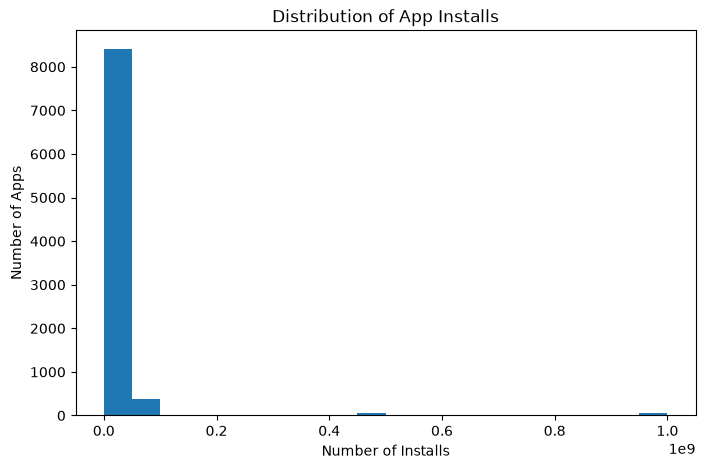

In [14]:
# Install Statistics
display(df["Installs"].describe())

# Top 10 Apps by Installs
top_installs = df.nlargest(10, "Installs")[["App", "Installs"]]

display(top_installs)

# Distribution of Installs
plt.figure(figsize=(8,5))

plt.hist(df["Installs"], bins=20)

plt.title("Distribution of App Installs")
plt.xlabel("Number of Installs")
plt.ylabel("Number of Apps")

plt.show()

# Free vs Paid Apps

Type
Free    8279
Paid     613
0          1
Name: count, dtype: int64

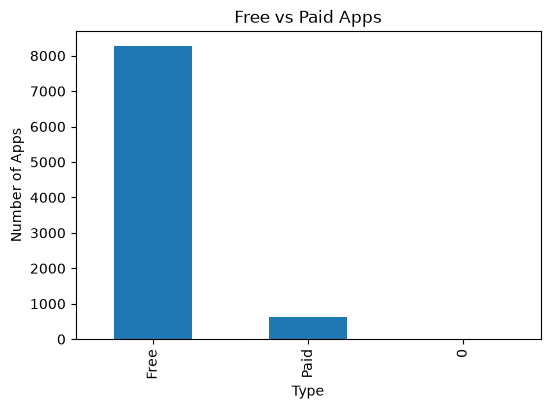

Type
0       19.000000
Free     4.182425
Paid     4.261501
Name: Rating, dtype: float64

In [16]:
# Number of Free vs Paid Apps
type_counts = df["Type"].value_counts()

display(type_counts)

plt.figure(figsize=(6,4))

type_counts.plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("Type")
plt.ylabel("Number of Apps")

plt.show()

# Average Rating
display(df.groupby("Type")["Rating"].mean())

# Correlation Analysis

In [18]:
# Convert Reviews to numeric
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Select only numeric columns
corr = df[["Rating", "Reviews", "Installs", "Price"]].corr()

display(corr)

# Correlation with Rating
display(corr["Rating"].sort_values(ascending=False))

,Rating,Reviews,Installs,Price
Rating,1.000000,0.068732,0.050886,-0.022355
Reviews,0.068732,1.000000,0.633429,-0.009558
Installs,0.050886,0.633429,1.000000,-0.011329
Price,-0.022355,-0.009558,-0.011329,1.000000


Rating      1.000000
Reviews     0.068732
Installs    0.050886
Price      -0.022355
Name: Rating, dtype: float64

# Rating vs Reviews

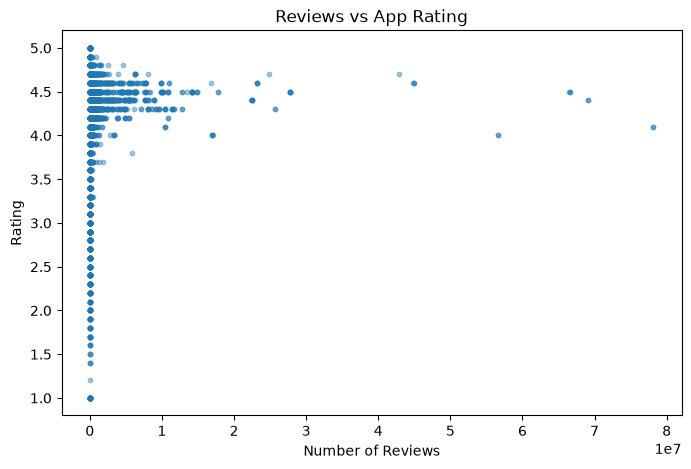

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Reviews"],
    df["Rating"],
    alpha=0.4,
    s=10
)

plt.title("Reviews vs App Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()